## Import Packages and Data Preparation

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder

from sklearn.cluster import KMeans

from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

from sklearn.mixture import GaussianMixture

import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import adjusted_rand_score, fowlkes_mallows_score

In [3]:
from google.colab import drive
drive.mount('/content/drive')
filepath = '/content/drive/My Drive/DSA3101/BankChurners.csv'
df = pd.read_csv(filepath)

Mounted at /content/drive


In [4]:
df

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.999910
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.999940
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.999980
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.999870
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.999980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,772366833,Existing Customer,50,M,2,Graduate,Single,$40K - $60K,Blue,40,...,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462,0.000191,0.999810
10123,710638233,Attrited Customer,41,M,2,Unknown,Divorced,$40K - $60K,Blue,25,...,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511,0.995270,0.004729
10124,716506083,Attrited Customer,44,F,1,High School,Married,Less than $40K,Blue,36,...,5409.0,0,5409.0,0.819,10291,60,0.818,0.000,0.997880,0.002118
10125,717406983,Attrited Customer,30,M,2,Graduate,Unknown,$40K - $60K,Blue,36,...,5281.0,0,5281.0,0.535,8395,62,0.722,0.000,0.996710,0.003294


# Data Processing

### Encoding Categorical Data

In [18]:
df.columns

Index(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'],
      dtype='object')

In [9]:
df_subset = df[['Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count',
                'Months_Inactive_12_mon','Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal','Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
                'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']]

In [11]:
df_subset.dtypes

,0
Customer_Age,int64
Gender,object
Dependent_count,int64
Education_Level,object
Marital_Status,object
Income_Category,object
Card_Category,object
Months_on_book,int64
Total_Relationship_Count,int64
Months_Inactive_12_mon,int64


In [12]:
for col in df_subset[['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']]:
    print(df_subset[col].unique())

['M' 'F']
['High School' 'Graduate' 'Uneducated' 'Unknown' 'College' 'Post-Graduate'
 'Doctorate']
['Married' 'Single' 'Unknown' 'Divorced']
['$60K - $80K' 'Less than $40K' '$80K - $120K' '$40K - $60K' '$120K +'
 'Unknown']
['Blue' 'Gold' 'Silver' 'Platinum']


In [13]:
df_subset = df_subset.copy()

# Using Label Encoding for Gender & Martial_Status
label_encoder = LabelEncoder()

df_subset['Gender'] = label_encoder.fit_transform(df_subset['Gender'])
df_subset['Marital_Status'] = label_encoder.fit_transform(df_subset['Marital_Status'])

In [14]:
df_subset = df_subset.copy()

# Define ordered categories
education_order = ['Unknown', 'Uneducated', 'High School', 'College', 'Graduate', 'Post-Graduate', 'Doctorate']
income_order = ['Unknown', 'Less than $40K', '$40K - $60K', '$60K - $80K', '$80K - $120K', '$120K +']
card_order = ["Blue", "Silver", "Gold", "Platinum"]

# Ensure the columns are strings
df_subset['Education_Level'] = df_subset['Education_Level'].astype(str)
df_subset['Income_Category'] = df_subset['Income_Category'].astype(str)
df_subset['Card_Category'] = df_subset['Card_Category'].astype(str)

In [15]:
# Apply Ordinal Encoding
ordinal_encoder_education = OrdinalEncoder(categories=[education_order], handle_unknown='use_encoded_value', unknown_value=np.nan)
df_subset['Education_Level'] = ordinal_encoder_education.fit_transform(df_subset[['Education_Level']]).astype(float)

ordinal_encoder_income = OrdinalEncoder(categories=[income_order], handle_unknown='use_encoded_value', unknown_value=np.nan)
df_subset['Income_Category'] = ordinal_encoder_income.fit_transform(df_subset[['Income_Category']]).astype(float)

ordinal_encoder_card = OrdinalEncoder(categories=[card_order], handle_unknown='use_encoded_value', unknown_value=np.nan)
df_subset['Card_Category'] = ordinal_encoder_card.fit_transform(df_subset[['Card_Category']]).astype(float)

In [16]:
df_subset.dtypes

,0
Customer_Age,int64
Gender,int64
Dependent_count,int64
Education_Level,float64
Marital_Status,int64
Income_Category,float64
Card_Category,float64
Months_on_book,int64
Total_Relationship_Count,int64
Months_Inactive_12_mon,int64


In [17]:
kmeans_data  = df_subset.copy()
kmeans_data_clustered = df_subset.copy()
gmm_data  = df_subset.copy()
gmm_data_clustered = df_subset.copy()
hc_data  = df_subset.copy()
hc_data_clustered = df_subset.copy()
dbscan_data  = df_subset.copy()
dbscan_data_clustered = df_subset.copy()
df_cleaned = df_subset.copy()

### Viewing data

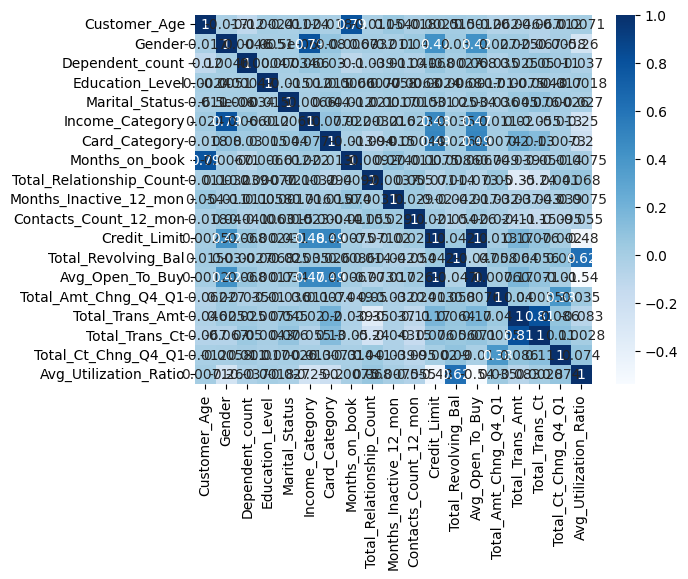

In [19]:
corr = df_subset.corr()
sns.heatmap(corr, cmap="Blues", annot=True)
sns.set_theme(rc={'figure.figsize':(10,10)})

### Feature Scaling

We will now apply feature scaling to

In [20]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cleaned)

In [21]:
df_scaled = pd.DataFrame(df_scaled)

df_scaled.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,-0.165406,1.059956,0.503368,-0.354022,-0.628128,0.620039,-0.250587,0.384621,0.763943,-1.327136,0.492404,0.446622,-0.473422,0.488971,2.623494,-0.959707,-0.973895,3.834003,-0.775882
1,0.333570,-0.943436,2.043199,0.822218,0.727306,-0.736292,-0.250587,1.010715,1.407306,-1.327136,-0.411616,-0.041367,-0.366667,-0.008486,3.563293,-0.916433,-1.357340,12.608573,-0.616276
2,0.583058,1.059956,0.503368,0.822218,-0.628128,1.298204,-0.250587,0.008965,0.120579,-1.327136,-2.219655,-0.573698,-1.426858,-0.445658,8.367214,-0.740982,-1.911206,6.807864,-0.997155
3,-0.789126,-0.943436,1.273283,-0.354022,2.082739,-0.736292,-0.250587,-0.241473,-0.522785,1.641478,-1.315636,-0.585251,1.661686,-0.734100,2.942843,-0.951758,-1.911206,6.807864,1.759686
4,-0.789126,1.059956,0.503368,-0.942142,-0.628128,0.620039,-0.250587,-1.869317,0.763943,-1.327136,-2.219655,-0.430877,-1.426858,-0.302868,6.455682,-1.056263,-1.570365,7.509325,-0.997155


# Hierarchical Clustering

## Modelling

### Plotting Dendrogram

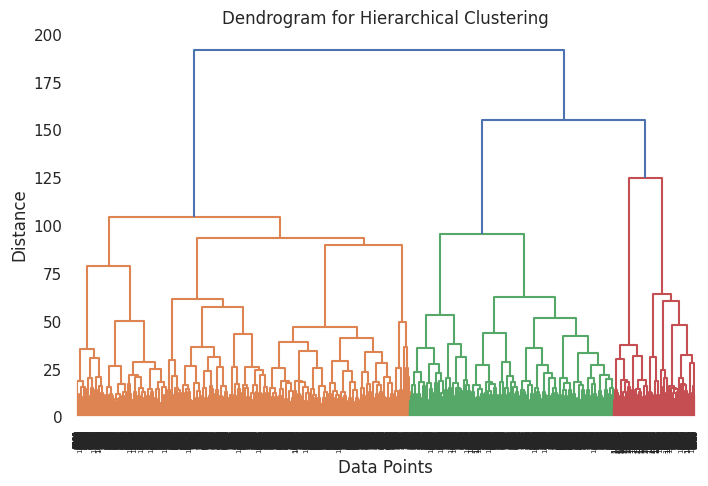

In [22]:
# Create the linkage matrix
linkage_matrix = sch.linkage(df_scaled, method='ward')

# Plot the dendrogram
plt.figure(figsize=(8, 5))
sch.dendrogram(linkage_matrix)
plt.title("Dendrogram for Hierarchical Clustering")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

### Running Hierarchical Clustering

In [23]:
# We will use 5 clusters as suggested by the Dendrogram
hc = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
hc_clustered = hc.fit_predict(df_scaled)

In [24]:
hc_segmented = hc_clustered.copy()

hc_data_clustered['Cluster'] = hc_segmented

## Plotting Clusters Distribution

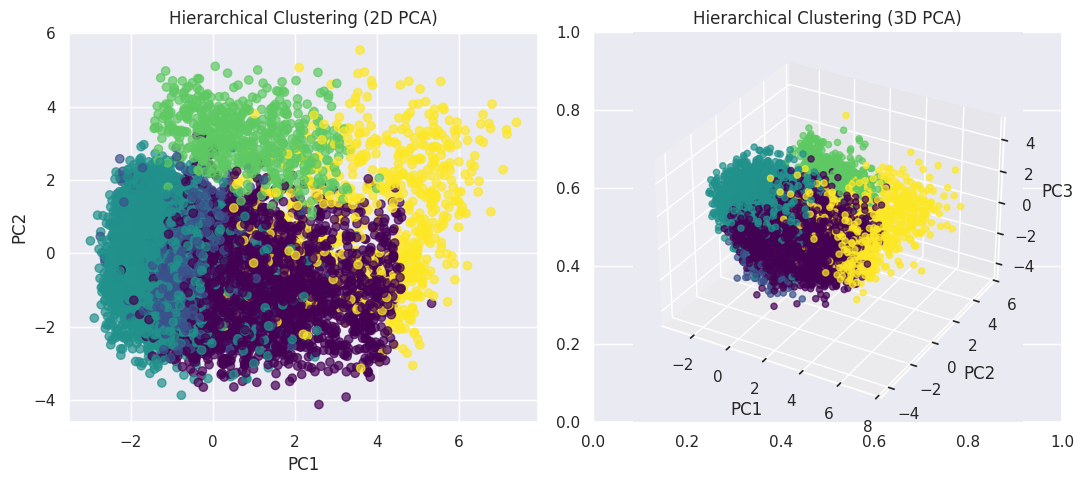

In [25]:
# Reduce dimensions to 2 for visualization
pca_2d = PCA(n_components=2)
df_pca_2d = pca_2d.fit_transform(df_scaled)

# Reduce dimensions to 3 for visualization
pca_3d = PCA(n_components=3)
df_pca_3d = pca_3d.fit_transform(df_scaled)

# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(11, 5), subplot_kw={'projection': None})

# 2D Scatter Plot
axes[0].scatter(df_pca_2d[:, 0], df_pca_2d[:, 1], c=hc_clustered, cmap='viridis', alpha=0.7)
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_title("Hierarchical Clustering (2D PCA)")
axes[0].grid(True)

# 3D Scatter Plot
ax3d = fig.add_subplot(1, 2, 2, projection='3d')
ax3d.scatter(df_pca_3d[:, 0], df_pca_3d[:, 1], df_pca_3d[:, 2], c=hc_clustered, cmap='viridis', alpha=0.7)
ax3d.set_xlabel("PC1")
ax3d.set_ylabel("PC2")
ax3d.set_zlabel("PC3")
ax3d.set_title("Hierarchical Clustering (3D PCA)")

plt.tight_layout()
plt.show()

In [26]:
# Printing number of data points in each cluster
cluster_counts = pd.Series(hc_clustered).value_counts().sort_index()

print("Number of data points in each cluster:")
print(cluster_counts)

Number of data points in each cluster:
0    3333
1    1507
2    3956
3     564
4     767
Name: count, dtype: int64


## Plotting Distrbution within Clusters

### Customer Attributes

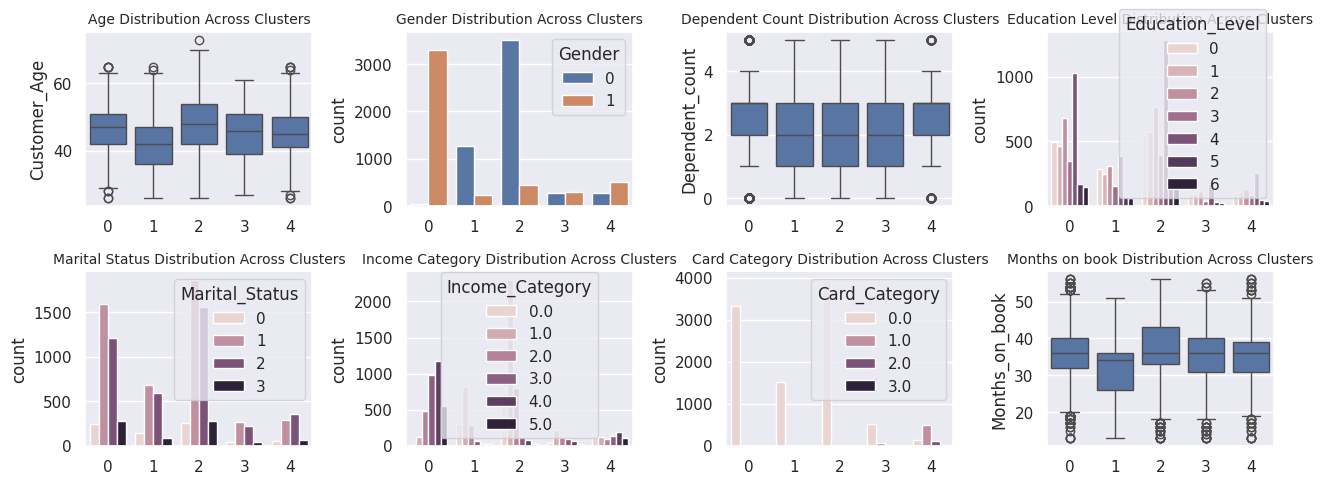

In [27]:
# Create a figure with 2 row and 4 columns
fig, axes = plt.subplots(2, 4, figsize=(13, 5))

# Plot Age Distribution
sns.boxplot(x=hc_clustered, y=hc_data['Customer_Age'], ax=axes[0, 0])
axes[0, 0].set_title("Age Distribution Across Clusters", fontsize=10)

# Plot Gender Distribution
sns.countplot(x=hc_clustered, hue=hc_data['Gender'], ax=axes[0, 1])
axes[0, 1].set_title("Gender Distribution Across Clusters", fontsize=10)

# Plot Dependent Count Distribution
sns.boxplot(x=hc_clustered, y=hc_data['Dependent_count'], ax=axes[0, 2])
axes[0, 2].set_title("Dependent Count Distribution Across Clusters", fontsize=10)

# Plot Education Level Distribution
sns.countplot(x=hc_clustered, hue=hc_data['Education_Level'], ax=axes[0 , 3])
axes[0, 3].set_title("Education Level Distribution Across Clusters", fontsize=10)

# Plot Marital Status Distribution
sns.countplot(x=hc_clustered, hue=hc_data['Marital_Status'], ax=axes[1, 0])
axes[1, 0].set_title("Marital Status Distribution Across Clusters", fontsize=10)

# Plot Income Category Distribution
sns.countplot(x=hc_clustered, hue=hc_data['Income_Category'], ax=axes[1, 1])
axes[1, 1].set_title("Income Category Distribution Across Clusters", fontsize=10)

# Plot Card Category Distribution
sns.countplot(x=hc_clustered, hue=hc_data['Card_Category'], ax=axes[1, 2])
axes[1, 2].set_title("Card Category Distribution Across Clusters", fontsize=10)

# Plot Months_on_book Distribution
sns.boxplot(x=hc_clustered, y=hc_data['Months_on_book'], ax=axes[1, 3])
axes[1, 3].set_title("Months on book Distribution Across Clusters", fontsize=10)

# Adjust the layout to avoid overlapping
plt.tight_layout()
plt.show()

In [28]:
# Using the ‘groupby’ method to group the cluster value and inspect the mean value of each of the attributes in the dataset using the ‘mean’ method.
hc_data_clustered.groupby('Cluster').mean()[['Customer_Age', 'Gender', 'Dependent_count',	'Education_Level',	'Marital_Status',	'Income_Category',	'Card_Category',	'Months_on_book']]

,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book
Cluster,,,,,,,,
0,46.535854,0.990699,2.572157,2.615062,1.458746,3.461746,0.001500,36.193819
1,41.383543,0.155275,2.261447,2.370272,1.412077,1.173192,0.000000,31.319841
2,48.370071,0.112487,2.172396,2.672649,1.467897,1.185288,0.001769,37.749747
3,45.102837,0.508865,2.195035,2.464539,1.452128,2.012411,0.097518,34.976950
4,45.481095,0.653194,2.538462,2.736636,1.569752,2.597132,1.016949,35.135593


### Transactional Data

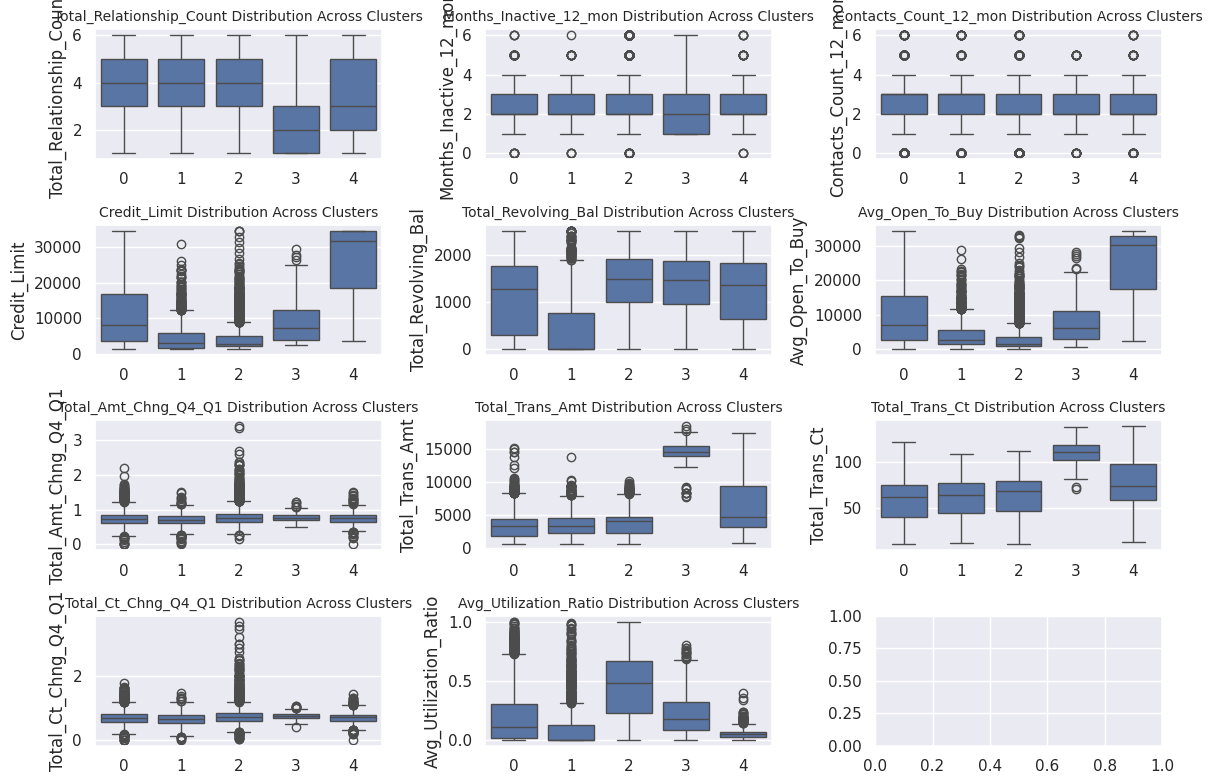

In [29]:
# Create a figure with 2 row and 3 columns
fig, axes = plt.subplots(4, 3, figsize=(12, 8))

sns.boxplot(x=hc_clustered, y=hc_data['Total_Relationship_Count'], ax=axes[0, 0])
axes[0, 0].set_title("Total_Relationship_Count Distribution Across Clusters", fontsize=10)

sns.boxplot(x=hc_clustered, y=hc_data['Months_Inactive_12_mon'], ax=axes[0, 1])
axes[0, 1].set_title("Months_Inactive_12_mon Distribution Across Clusters", fontsize=10)

sns.boxplot(x=hc_clustered, y=hc_data['Contacts_Count_12_mon'], ax=axes[0, 2])
axes[0, 2].set_title("Contacts_Count_12_mon Distribution Across Clusters", fontsize=10)

sns.boxplot(x=hc_clustered, y=hc_data['Credit_Limit'], ax=axes[1, 0])
axes[1, 0].set_title("Credit_Limit Distribution Across Clusters", fontsize=10)

sns.boxplot(x=hc_clustered, y=hc_data['Total_Revolving_Bal'], ax=axes[1, 1])
axes[1, 1].set_title("Total_Revolving_Bal Distribution Across Clusters", fontsize=10)

sns.boxplot(x=hc_clustered, y=hc_data['Avg_Open_To_Buy'], ax=axes[1, 2])
axes[1, 2].set_title("Avg_Open_To_Buy Distribution Across Clusters", fontsize=10)

sns.boxplot(x=hc_clustered, y=hc_data['Total_Amt_Chng_Q4_Q1'], ax=axes[2, 0])
axes[2, 0].set_title("Total_Amt_Chng_Q4_Q1 Distribution Across Clusters", fontsize=10)

sns.boxplot(x=hc_clustered, y=hc_data['Total_Trans_Amt'], ax=axes[2, 1])
axes[2, 1].set_title("Total_Trans_Amt Distribution Across Clusters", fontsize=10)

sns.boxplot(x=hc_clustered, y=hc_data['Total_Trans_Ct'], ax=axes[2, 2])
axes[2, 2].set_title("Total_Trans_Ct Distribution Across Clusters", fontsize=10)

sns.boxplot(x=hc_clustered, y=hc_data['Total_Ct_Chng_Q4_Q1'], ax=axes[3, 0])
axes[3, 0].set_title("Total_Ct_Chng_Q4_Q1 Distribution Across Clusters", fontsize=10)

sns.boxplot(x=hc_clustered, y=hc_data['Avg_Utilization_Ratio'], ax=axes[3, 1])
axes[3, 1].set_title("Avg_Utilization_Ratio Distribution Across Clusters", fontsize=10)

# Adjust the layout to avoid overlapping
plt.tight_layout()
plt.show()

In [30]:
# Using the ‘groupby’ method to group the cluster value and inspect the mean value of each of the attributes in the dataset using the ‘mean’ method.
hc_data_clustered.groupby('Cluster').mean()[['Total_Relationship_Count', 'Credit_Limit', 'Avg_Open_To_Buy',	'Total_Trans_Amt',	'Total_Trans_Ct',	'Avg_Utilization_Ratio']]

,Total_Relationship_Count,Credit_Limit,Avg_Open_To_Buy,Total_Trans_Amt,Total_Trans_Ct,Avg_Utilization_Ratio
Cluster,,,,,,
0,3.942694,11443.730123,10279.645215,3435.159016,58.661566,0.204265
1,3.885202,4546.830325,4148.862177,3523.972794,61.079628,0.098979
2,3.981547,4237.820854,2820.638094,3604.635996,62.870829,0.452448
3,2.312057,8867.157801,7509.959220,14631.301418,109.897163,0.220819
4,3.336375,26930.734029,25725.584094,6946.774446,76.348110,0.051425


## Cluster Analysis

*   **Cluster 0: Mid-High Income Males with Dependents, Strong Banking Relationship**
      - Likely financially stable men managing family expenses with good banking engagement and responsible credit use.
*   **Cluster 1: Young, Low-Income Females with Shortest Tenure & Low Credit**
      - Newer bank customers with limited financial history, lower credit access, and cautious spending.
*   **Cluster 2: Older, Low-Income Females with Strong Banking Relationship & High Utilisation**
      - Long-term customers with lower incomes, relying heavily on credit, possibly facing financial constraints.
*  **Cluster 3: Mid-Income Graduates with High Spending & Transactions**
      - Likely financially independent individuals who spend actively but don’t engage deeply with the bank.
*   **Cluster 4: Educated, Single Individuals with High Credit & Low Utilisation**
      - Financially stable, independent, and responsible spenders who manage credit well.




# Customer Behaviour
Investigate:
- How do customer behaviours vary across different segments?
- **Objective**: Analyze patterns in product usage, transaction history, and digital engagement among various customer segments
- **Expected Outcome**: Use insights to recommend targeted marketing approaches for each segment

In [35]:
hc_data['Cluster'] = hc_clustered

In [36]:
# splitting original df according to clusters
c0 = hc_data[hc_data['Cluster'] == 0]
c1 = hc_data[hc_data['Cluster'] == 1]
c2 = hc_data[hc_data['Cluster'] == 2]
c3 = hc_data[hc_data['Cluster'] == 3]
c4 = hc_data[hc_data['Cluster'] == 4]

Some of the useful features for analysing customer behaviours  
- Months on book: period of relationship with bank;
- Attrition Flag: whether customer still using the bank's services
- Dependenct_counts: how many individuals are fianancially dependent on the customer
- Total Relationship Count: number of products held by the customer
- Months inactive: no. of months inactive in the past 12 months
- Contacts count: number of contacts with the bank in the past 12 months
- Credit Limit: credit card limit
- Avg open to buy: avg available budget/credit for future purchases
- Change to transaction amt Q4 to Q1: ratio change in transaction amt
- credit utilization ratio: how much credit is used

## Transaction History Analysis

To analyse the transaction history, examine the following columns  
- Total_Amt_Chng_Q4_Q1
- Total_Trans_Amt
- Total_Trans_Ct
- Total_Ct_Chng_Q4_Q1

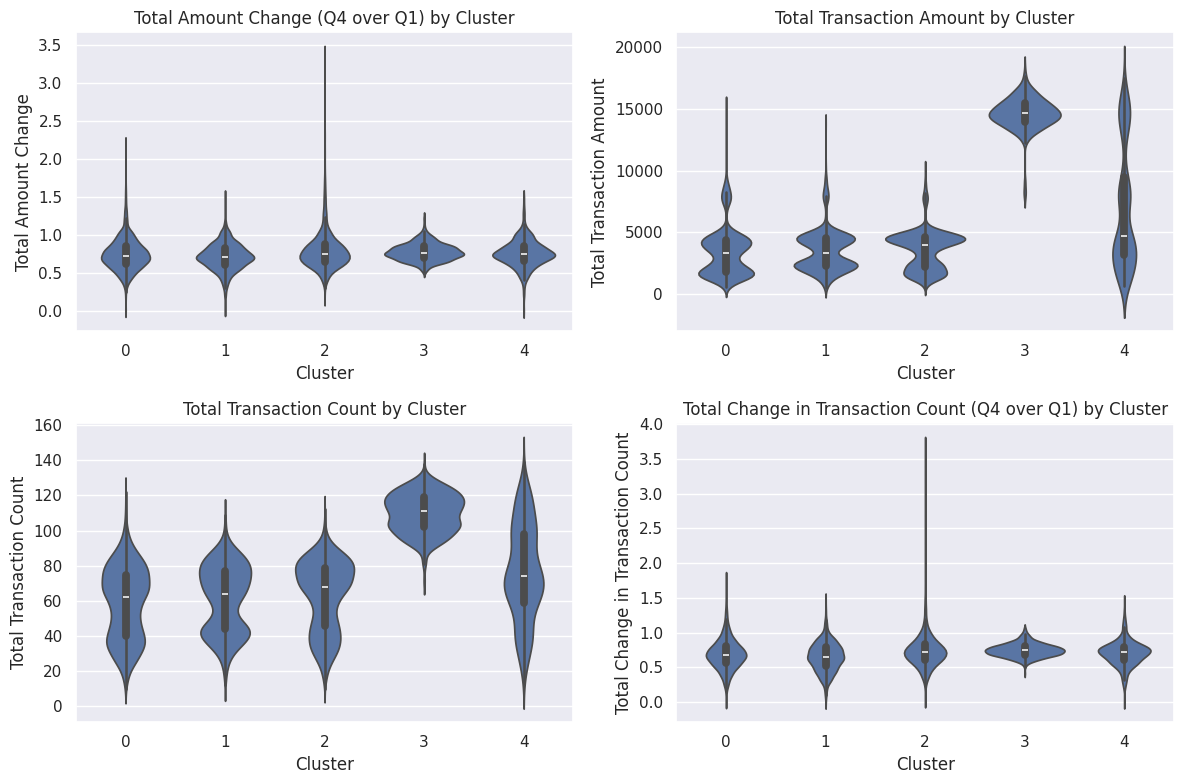

In [67]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.violinplot(x='Cluster', y='Total_Amt_Chng_Q4_Q1', data=hc_data, ax=axes[0, 0])
axes[0, 0].set_title('Total Amount Change (Q4 over Q1) by Cluster')
axes[0, 0].set_ylabel('Total Amount Change')

sns.violinplot(x='Cluster', y='Total_Trans_Amt', data=hc_data, ax=axes[0, 1])
axes[0, 1].set_title('Total Transaction Amount by Cluster')
axes[0, 1].set_ylabel('Total Transaction Amount')

sns.violinplot(x='Cluster', y='Total_Trans_Ct', data=hc_data, ax=axes[1, 0])
axes[1, 0].set_title('Total Transaction Count by Cluster')
axes[1, 0].set_ylabel('Total Transaction Count')

sns.violinplot(x='Cluster', y='Total_Ct_Chng_Q4_Q1', data=hc_data, ax=axes[1, 1])
axes[1, 1].set_title('Total Change in Transaction Count (Q4 over Q1) by Cluster')
axes[1, 1].set_ylabel('Total Change in Transaction Count')

plt.tight_layout()

plt.show()

## Product Usage


- Total_Relationship_Count

- Total_Revolving_Bal
- Avg_Open_To_Buy
- Avg_Utilization_Ratio

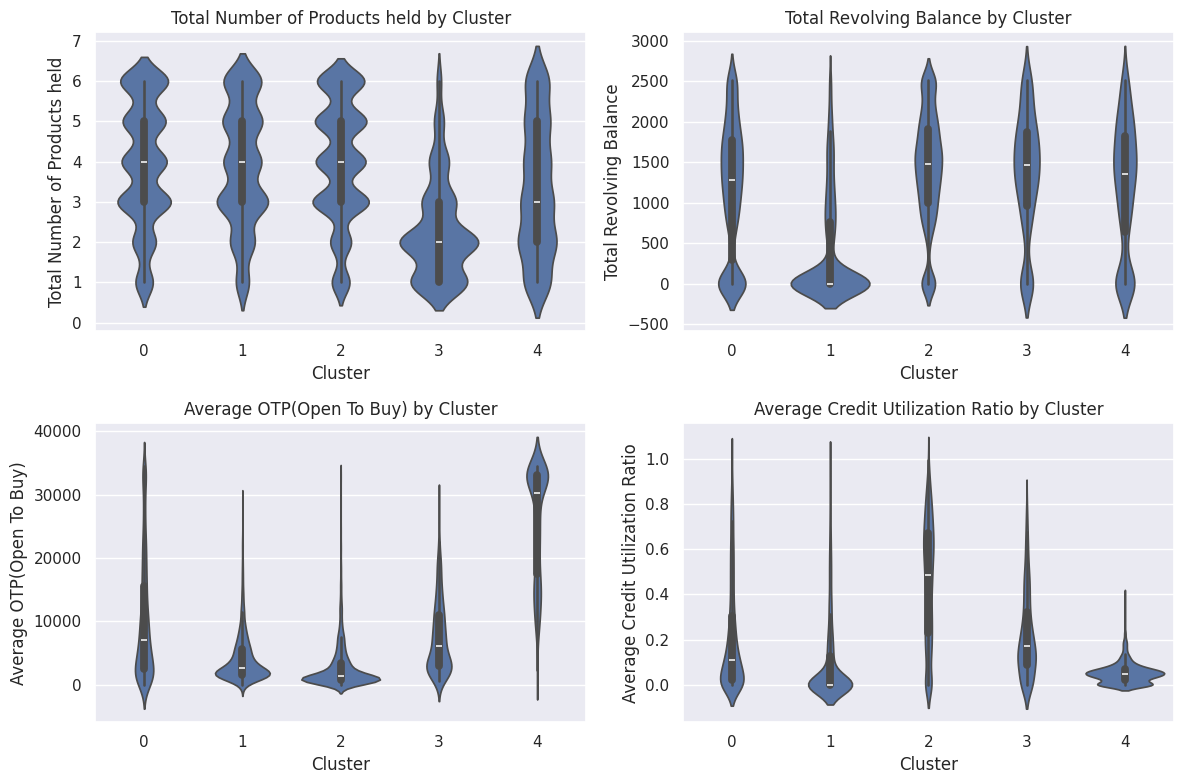

In [68]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.violinplot(x='Cluster', y='Total_Relationship_Count', data=hc_data, ax=axes[0, 0])
axes[0, 0].set_title('Total Number of Products held by Cluster')
axes[0, 0].set_ylabel('Total Number of Products held')

sns.violinplot(x='Cluster', y='Total_Revolving_Bal', data=hc_data, ax=axes[0, 1])
axes[0, 1].set_title('Total Revolving Balance by Cluster')
axes[0, 1].set_ylabel('Total Revolving Balance')

sns.violinplot(x='Cluster', y='Avg_Open_To_Buy', data=hc_data, ax=axes[1, 0])
axes[1, 0].set_title('Average OTP(Open To Buy) by Cluster')
axes[1, 0].set_ylabel('Average OTP(Open To Buy)')

sns.violinplot(x='Cluster', y='Avg_Utilization_Ratio', data=hc_data, ax=axes[1, 1])
axes[1, 1].set_title('Average Credit Utilization Ratio by Cluster')
axes[1, 1].set_ylabel('Average Credit Utilization Ratio')

plt.tight_layout()

plt.show()

## (Digital) Engagement

Features to be analysed:  
- Months_on_book
- Months_Inactive_12_mon
- Contacts_Count_12_mon

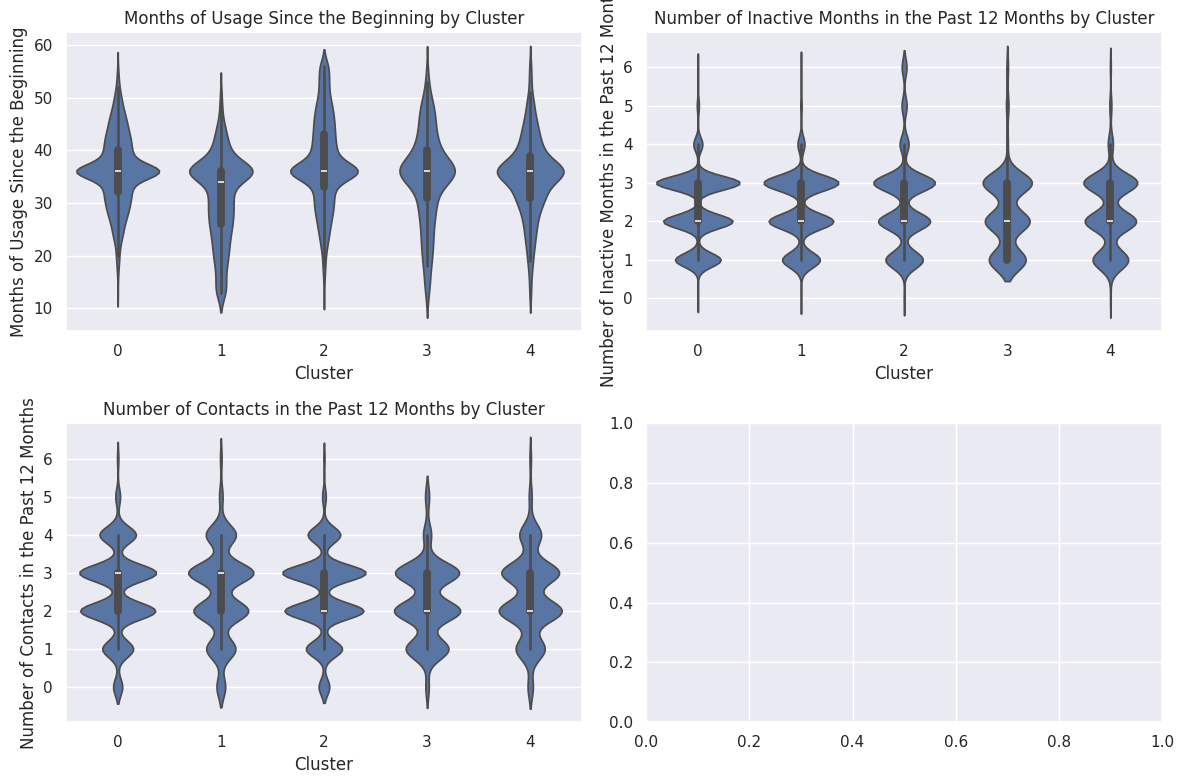

In [69]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.violinplot(x='Cluster', y='Months_on_book', data=hc_data, ax=axes[0, 0])
axes[0, 0].set_title('Months of Usage Since the Beginning by Cluster')
axes[0, 0].set_ylabel('Months of Usage Since the Beginning')

sns.violinplot(x='Cluster', y='Months_Inactive_12_mon', data=hc_data, ax=axes[0, 1])
axes[0, 1].set_title('Number of Inactive Months in the Past 12 Months by Cluster')
axes[0, 1].set_ylabel('Number of Inactive Months in the Past 12 Months')

sns.violinplot(x='Cluster', y='Contacts_Count_12_mon', data=hc_data, ax=axes[1, 0])
axes[1, 0].set_title('Number of Contacts in the Past 12 Months by Cluster')
axes[1, 0].set_ylabel('Number of Contacts in the Past 12 Months')

plt.tight_layout()

plt.show()

## Other Factors
These are the factors that suggest the profile of customers
- Dependent_count
- Credit_Limit
- Card_Category

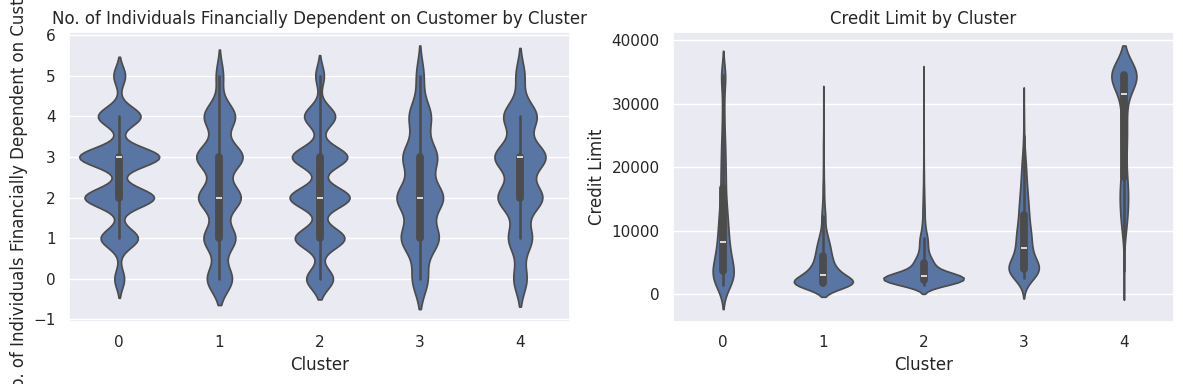

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.violinplot(x='Cluster', y='Dependent_count', data=hc_data, ax=axes[0])
axes[0].set_title('No. of Individuals Financially Dependent on Customer by Cluster')
axes[0].set_ylabel('No. of Individuals Financially Dependent on Customer')

sns.violinplot(x='Cluster', y='Credit_Limit', data=hc_data, ax=axes[1])
axes[1].set_title('Credit Limit by Cluster')
axes[1].set_ylabel('Credit Limit')

plt.tight_layout()

plt.show()

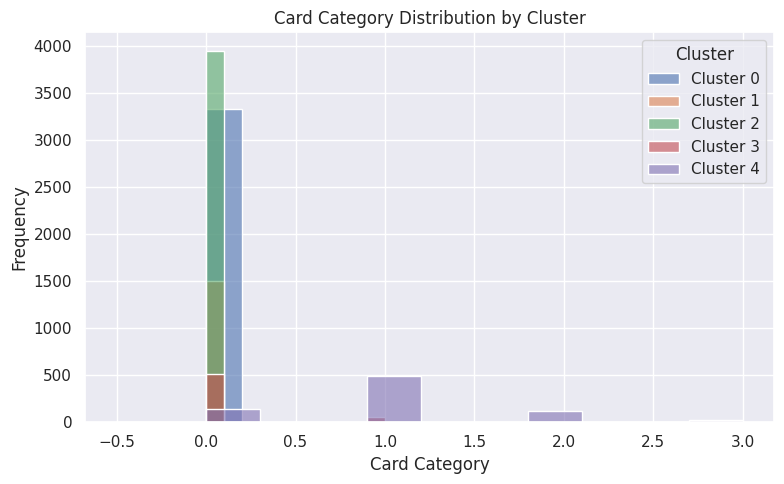

In [66]:
num_clusters = 5

fig, ax = plt.subplots(figsize=(8, 5))

for i in range(num_clusters):
    cluster_data = hc_data[hc_data['Cluster'] == i]
    sns.histplot(cluster_data['Card_Category'], kde=False, bins=10, ax=ax, label=f'Cluster {i}', alpha=0.6)

ax.set_title('Card Category Distribution by Cluster')
ax.set_xlabel('Card Category')
ax.set_ylabel('Frequency')

ax.legend(title='Cluster')

plt.tight_layout()
plt.show()